In [2]:
import sys
!{sys.executable} -m pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 11.9 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 22.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [cartopy]m2/3 [cartopy]


In [1]:
import sys
print(sys.executable)

import cartopy.crs as ccrs
import cartopy.feature as cfeature

print("cartopy works")

/opt/anaconda3/envs/climlab_env/bin/python
cartopy works


✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2025-May-23 22:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local


/opt/anaconda3/envs/climlab_env/lib/python3.10/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/opt/anaconda3/envs/climlab_env/lib/python3.10/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_2_counties.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


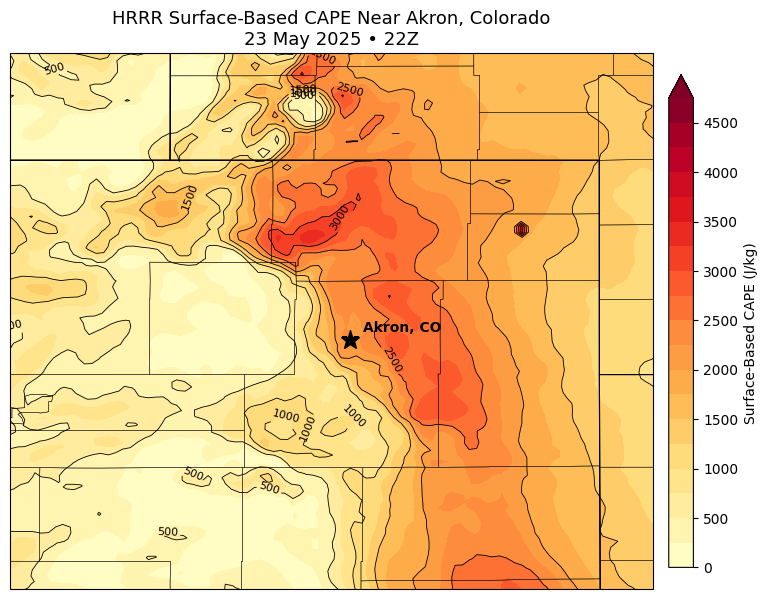

Saved as akron_co_sbcape_20250523_22z.png


In [3]:
from datetime import datetime
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.feature import NaturalEarthFeature
from herbie import Herbie
import numpy as np

date = datetime(2025, 5, 23, 22)
akron_lat = 40.1605
akron_lon = -103.2144

H = Herbie(date, model="hrrr", product="sfc", fxx=0)
ds = H.xarray("CAPE:surface")

cape = ds["cape"]
lats = ds["latitude"]
lons = ds["longitude"]

fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([-104.8, -101.8, 39.0, 41.5], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.STATES, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

counties = NaturalEarthFeature(
    category="cultural",
    name="admin_2_counties",
    scale="10m",
    facecolor="none"
)

ax.add_feature(counties, linewidth=0.3)

levels = np.arange(0, 5000, 250)

cape_plot = ax.contourf(
    lons,
    lats,
    cape,
    levels=levels,
    cmap="YlOrRd",
    extend="max",
    transform=ccrs.PlateCarree()
)

cape_contours = ax.contour(
    lons,
    lats,
    cape,
    levels=np.arange(500, 5000, 500),
    colors="black",
    linewidths=0.6,
    transform=ccrs.PlateCarree()
)

ax.clabel(
    cape_contours,
    inline=True,
    fontsize=8,
    fmt="%d"
)

ax.plot(
    akron_lon,
    akron_lat,
    marker="*",
    markersize=14,
    color="black",
    transform=ccrs.PlateCarree()
)

ax.text(
    akron_lon + 0.06,
    akron_lat + 0.04,
    "Akron, CO",
    fontsize=10,
    weight="bold",
    transform=ccrs.PlateCarree()
)

cbar = plt.colorbar(
    cape_plot,
    ax=ax,
    pad=0.02,
    shrink=0.8
)

cbar.set_label("Surface-Based CAPE (J/kg)")

ax.set_title(
    "HRRR Surface-Based CAPE Near Akron, Colorado\n23 May 2025 • 22Z",
    fontsize=13
)

plt.savefig(
    "akron_co_sbcape_20250523_22z.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Saved as akron_co_sbcape_20250523_22z.png")